In [1]:
import os
import os.path as op
from os.path import join
from os import makedirs

# pandas is a dataframe-managing library and it's the absolute coolest
import pandas as pd

# numpy is short for "numerical python" and it does math
import numpy as np

# nibabel handles nifti images
import nibabel as nib

# nilearn makes the best brain plots
# and their documentation/examples are so, so handy
# https://nilearn.github.io/stable/auto_examples/01_plotting/index.html
from nilearn import datasets
from nilearn.plotting.cm import _cmap_d as nilearn_cmaps
from nilearn.maskers import NiftiMasker
from nilearn.image import threshold_img, index_img, resample_to_img
from nilearn.plotting import plot_stat_map
from nilearn.reporting import get_clusters_table

# matplotlib is the backbone of most python plotting
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

from neuromaps import transforms
from neuromaps.datasets import fetch_fslr

from nimare.decode.continuous import CorrelationDecoder
from nimare.transforms import p_to_z

from IPython.display import display
from surfplot import Plot


from gradec.fetcher import _fetch_features, _fetch_frequencies, _fetch_classification
from gradec.utils import _decoding_filter
from gradec.utils import _zero_medial_wall

from gradec.plot import plot_radar, plot_cloud

In [2]:
data_dir = "./dset"
deriv_dir = join(data_dir, "derivatives")
decoding_dir = "./decoding"
atlas_dir = join(data_dir, "HCPex_2mm")

# Load HCPex atlas once for re-use in volume and surface overlays
atlas_hcpex_filename = join(atlas_dir, "HCPex_2mm.nii")
hcpex_img = nib.load(atlas_hcpex_filename)
hcpex_data = np.rint(hcpex_img.get_fdata()).astype(np.int32)

# Replace these integers with the specific HCPex region IDs you want to trace
target_regions = [45, 82, 112, 205, 310] 

# Set any region label NOT in your target list to 0 (background)
filtered_data = np.where(np.isin(hcpex_data, target_regions), hcpex_data, 0)

# Overwrite the global hcpex_img with the newly filtered region data
hcpex_img = nib.Nifti1Image(filtered_data, hcpex_img.affine, hcpex_img.header)

# Precompute contour levels that trace parcel borders in volume space
hcpex_labels = np.unique(filtered_data)
hcpex_labels = hcpex_labels[hcpex_labels > 0]
hcpex_levels = (hcpex_labels - 0.5).tolist()

/Users/chloehampson/Desktop/habenula-comparison/.venv/lib/python3.9/site-packages/nilearn/plotting/img_plotting.py:608: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  img = new_img_like(roi_img, data, affine=roi_img.affine)


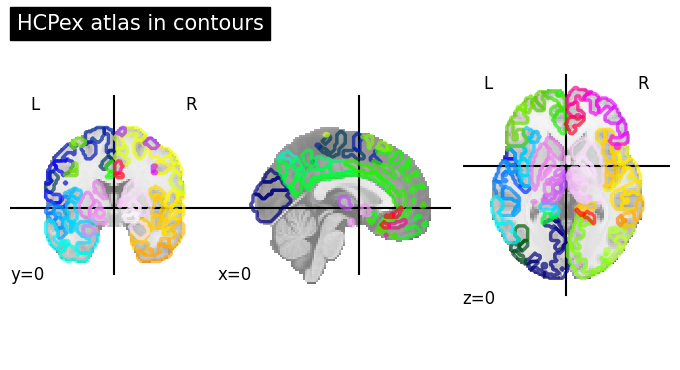

In [3]:
from nilearn.plotting import plot_roi, show

atlas_hcpex_filename = join(atlas_dir, "HCPex_2mm.nii")

plot_roi(
    atlas_hcpex_filename,
    view_type="contours",
    title="HCPex atlas in contours",
)
show()

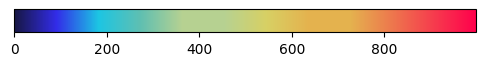

In [4]:
#CMAP = "Spectral_r"
# Define the number of colors in the colormap
num_colors = 1000

# Define anchor points for key colors using hex values
colors = [
    "#171744",  # Dark Blue
    "#322ce8",
    "#1cc5e3",  # light blue
    "#5fbfb1",
    "#b6d191",
    "#b6d191",
    "#d7d064",
    "#E4B24E",  # Yellow (adjusted)
    "#E4B24E",  # Yellow (adjusted)
    "#ed774d",  # Orange
    "#f63b4d",  # Orange
    "#ff004c",  # Red
]
# Create a smooth interpolation for the custom colormap
CMAP = LinearSegmentedColormap.from_list("custom_cmap", colors, N=num_colors)

# Plot the color gradient
plt.figure(figsize=(8, 2))
plt.imshow([list(range(num_colors))], aspect="auto", cmap=CMAP)
plt.gca().set_visible(False)
plt.colorbar(orientation="horizontal")
display(plt.gcf())
plt.close()

In [5]:
def trim_image(img=None, tol=1, fix=True):
    if fix:
        mask = img != tol
    else:
        mask = img <= tol
    if img.ndim == 3:
        mask = mask.any(2)
    mask0, mask1 = mask.any(0), mask.any(1)
    return img[np.ix_(mask1, mask0)]

In [6]:
def plot_vol(
    nii_img_thr, threshold, mask_contours=None, vmax=6, alpha=1, cmap=CMAP, dim=-0.45
):
    template = datasets.load_mni152_template(resolution=1)

    atlas_img = globals().get("hcpex_img", None)

    display_modes = ["x", "y", "z"]
    fig = plt.figure(figsize=(5, 5))
    fig.subplots_adjust(
        left=None, bottom=None, right=None, top=None, wspace=None, hspace=None
    )
    gs = GridSpec(2, 2, figure=fig)

    # Resample atlas to the statistical map space so contours align with the data.
    atlas_border_img = None
    if atlas_img is not None:
        atlas_rs = resample_to_img(atlas_img, nii_img_thr, interpolation="nearest")
        atlas_data = np.rint(atlas_rs.get_fdata()).astype(np.int32)

        # Build a 1-voxel border mask for parcel boundaries.
        border = np.zeros_like(atlas_data, dtype=np.uint8)
        for axis in range(3):
            a0 = np.take(
                atlas_data,
                indices=range(atlas_data.shape[axis] - 1),
                axis=axis,
            )
            a1 = np.take(
                atlas_data,
                indices=range(1, atlas_data.shape[axis]),
                axis=axis,
            )
            diff = (a0 != a1) & ((a0 > 0) | (a1 > 0))

            s0 = [slice(None)] * 3
            s1 = [slice(None)] * 3
            s0[axis] = slice(0, -1)
            s1[axis] = slice(1, None)

            border[tuple(s0)] |= diff
            border[tuple(s1)] |= diff

        atlas_border_img = nib.Nifti1Image(
            border.astype(np.int16), atlas_rs.affine, atlas_rs.header
        )

    for dsp_i, display_mode in enumerate(display_modes):
        if display_mode == "z":
            ax = fig.add_subplot(gs[:, 1], aspect="equal")
            colorbar = True
        else:
            ax = fig.add_subplot(gs[dsp_i, 0], aspect="equal")
            colorbar = False

        display = plot_stat_map(
            nii_img_thr,
            bg_img=template,
            black_bg=False,
            draw_cross=False,
            annotate=True,
            alpha=alpha,
            cmap=cmap,
            threshold=threshold,
            colorbar=colorbar,
            display_mode=display_mode,
            cut_coords=1,
            vmax=vmax,
            axes=ax,
            dim=dim,
        )

        # Atlas lines on top (thin parcel borders only).
        if atlas_border_img is not None:
            display.add_contours(
                atlas_border_img,
                levels=[0.5],
                colors="black",
                linewidths=0.7,
            )

    return fig

In [7]:
def plot_surf(nii_img_thr, mask_contours=None, vmax=8, cmap=CMAP):
    def _boundary_mask_from_labels(labels: np.ndarray, faces: np.ndarray) -> np.ndarray:
        """Return a 0/1 vertex mask for parcel borders based on face adjacency."""
        labels = labels.astype(np.int32, copy=False)
        faces = faces.astype(np.int64, copy=False)

        edges = np.vstack(
            [
                faces[:, [0, 1]],
                faces[:, [1, 2]],
                faces[:, [2, 0]],
            ]
        )
        l0 = labels[edges[:, 0]]
        l1 = labels[edges[:, 1]]
        diff = (l0 != l1) & ((l0 > 0) | (l1 > 0))

        boundary_vertices = np.unique(edges[diff].ravel())
        mask = np.zeros(labels.shape[0], dtype=np.int8)
        mask[boundary_vertices] = 1
        return mask

    map_lh, map_rh = transforms.mni152_to_fslr(nii_img_thr, fslr_density="32k")
    map_lh, map_rh = _zero_medial_wall(
        map_lh,
        map_rh,
        space="fsLR",
        density="32k",
    )

    surfaces = fetch_fslr(density="32k")
    lh, rh = surfaces["inflated"]
    sulc_lh, sulc_rh = surfaces["sulc"]

    # Load mesh faces so we can compute a 1-vertex-thick border mask
    faces_lh = nib.load(lh).darrays[1].data
    faces_rh = nib.load(rh).darrays[1].data

    p = Plot(surf_lh=lh, surf_rh=rh, layout="grid")
    p.add_layer({"left": sulc_lh, "right": sulc_rh}, cmap="binary_r", cbar=False)

    # activation layer
    p.add_layer(
        {"left": map_lh, "right": map_rh},
        cmap=cmap,
        cbar=False,
        color_range=(-vmax, vmax),
    )

    # atlas lines on top (project atlas as labels -> nearest)
    atlas_img = globals().get("hcpex_img", None)
    if atlas_img is not None:
        atlas_lh, atlas_rh = transforms.mni152_to_fslr(
            atlas_img, fslr_density="32k", method="nearest"
        )
        atlas_lh, atlas_rh = _zero_medial_wall(
            atlas_lh,
            atlas_rh,
            space="fsLR",
            density="32k",
        )
        atlas_arr_lh = np.rint(atlas_lh.agg_data()).astype(np.int32)
        atlas_arr_rh = np.rint(atlas_rh.agg_data()).astype(np.int32)
        atlas_arr_lh[atlas_arr_lh < 0] = 0
        atlas_arr_rh[atlas_arr_rh < 0] = 0

        atlas_border_lh = _boundary_mask_from_labels(atlas_arr_lh, faces_lh)
        atlas_border_rh = _boundary_mask_from_labels(atlas_arr_rh, faces_rh)

        atlas_line_cmap = ListedColormap(["black"], "atlas_outline", N=1)
        p.add_layer(
            {"left": atlas_border_lh, "right": atlas_border_rh},
            cmap=atlas_line_cmap,
            alpha=1,
            zero_transparent=True,
            cbar=False,
        )

    if mask_contours:
        mask_lh, mask_rh = transforms.mni152_to_fslr(
            mask_contours, fslr_density="32k", method="nearest"
        )
        mask_lh, mask_rh = _zero_medial_wall(
            mask_lh,
            mask_rh,
            space="fsLR",
            density="32k",
        )
        mask_arr_lh = mask_lh.agg_data()
        mask_arr_rh = mask_rh.agg_data()
        countours_lh = np.zeros_like(mask_arr_lh)
        countours_lh[mask_arr_lh != 0] = 1
        countours_rh = np.zeros_like(mask_arr_rh)
        countours_rh[mask_arr_rh != 0] = 1

        colors = [(0, 0, 0, 0)]
        contour_cmap = ListedColormap(colors, "regions", N=1)
        p.add_layer(
            {"left": countours_lh, "right": countours_rh},
            cmap=contour_cmap,
            cbar=False,
        )

    return p.build()

In [8]:
mask_img = datasets.load_mni152_brain_mask(resolution=2)
masker = NiftiMasker(mask_img=mask_img)
masker = masker.fit()

In [9]:
test_dict = {
    "1s": "Group Average (One-Sample T-Test)",
    "2s": "Group Comparison (Two-Sample Unpaired T-Test: ASD-TD)",
}

/var/folders/x1/rzvtxb3x273_5fvyk8ftl70r0000gn/T/ipykernel_42421/2558735287.py:31: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  cluster_df = pd.read_table(cluster_fn, skiprows=8, delim_whitespace=True, names=column_names)


Cluster correction table:
     pthr  .10000  .05000  .02000  .01000
0  0.0500  1457.0  1766.0  2186.0  2473.5
1  0.0200   505.9   615.3   757.0   870.0
2  0.0100   276.9   335.6   416.5   479.0
3  0.0050   164.7   200.0   250.0   293.0
4  0.0020    91.1   111.7   139.7   163.0
5  0.0010    61.3    75.5    93.8   111.4
6  0.0005    42.4    51.9    66.3    77.8
7  0.0002    26.5    33.0    43.7    50.5
8  0.0001    18.7    23.9    31.4    37.5
Total subjects: 1480, Group sizes: 661, 819

=== Processing Group Average (One-Sample T-Test) ===
File ./dset/derivatives/hb-conn/group-drawn/habenula/averaged/sub-group_task-rest_desc-1SampletTest.nii.gz already exists, skipping conversion.
Cluster extent: 37.5, p-threshold: 0.0001, z-threshold: 3.890591886413094


/Users/chloehampson/Desktop/habenula-comparison/.venv/lib/python3.9/site-packages/nilearn/maskers/nifti_masker.py:108: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(
/Users/chloehampson/Desktop/habenula-comparison/.venv/lib/python3.9/site-packages/nilearn/maskers/nifti_masker.py:108: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


Significant clusters:
   Cluster ID     X     Y     Z  Peak Stat Cluster Size (mm3)
0           1   3.5 -24.5   3.5  28.048861             480872
1          1a   3.5  -0.5   3.5  15.181170                   
2          1b  15.5 -30.5  -4.5  13.453623                   
3          1c   5.5   7.5  -0.5  12.664586                   
4           2 -22.5  -0.5  69.5   6.631356               1728
5          2a -14.5  -0.5  71.5   4.605451                   
6           3 -40.5  33.5  11.5   6.021825               3192
7          3a -38.5  19.5  23.5   5.315705                   
8          3b -46.5  23.5  19.5   5.018819                   
9          3c -46.5  21.5  29.5   4.779835                   
10          4  43.5 -14.5 -28.5   5.956895                488
11          5 -32.5 -56.5  45.5   5.669044               1144
12         5a -26.5 -64.5  41.5   4.614406                   
13          6  37.5 -18.5  39.5   5.620476               1048
14         6a  49.5 -14.5  45.5   5.378482      

/Users/chloehampson/Desktop/habenula-comparison/.venv/lib/python3.9/site-packages/nilearn/image/resampling.py:493: UserWarning: The provided image has no sform in its header. Please check the provided file. Results may not be as expected.
  warnings.warn(
/Users/chloehampson/Desktop/habenula-comparison/.venv/lib/python3.9/site-packages/nilearn/image/resampling.py:493: UserWarning: The provided image has no sform in its header. Please check the provided file. Results may not be as expected.
  warnings.warn(
/Users/chloehampson/Desktop/habenula-comparison/.venv/lib/python3.9/site-packages/nilearn/image/resampling.py:493: UserWarning: The provided image has no sform in its header. Please check the provided file. Results may not be as expected.
  warnings.warn(


...

Cluster extent: 38.6, p-threshold: 0.0001, z-threshold: 3.890591886413094


/Users/chloehampson/Desktop/habenula-comparison/.venv/lib/python3.9/site-packages/nilearn/maskers/nifti_masker.py:108: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(
/Users/chloehampson/Desktop/habenula-comparison/.venv/lib/python3.9/site-packages/nilearn/maskers/nifti_masker.py:108: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(
/Users/chloehampson/Desktop/habenula-comparison/.venv/lib/python3.9/site-packages/nilearn/reporting/_get_clusters_table.py:339: UserWarning: Attention: No clusters with stat lower than -3.890591886413094
  warnings.warn(
/User

Significant clusters:
  Cluster ID     X     Y     Z  Peak Stat Cluster Size (mm3)
0          1  63.5 -38.5  -0.5   5.405111                816
1         1a  59.5 -30.5   5.5   4.043229                   
2          2 -54.5 -20.5  -6.5   5.140213               1640
3         2a -60.5 -28.5   3.5   4.647803                   
4         2b -56.5  -8.5 -12.5   4.571720                   
5         2c -60.5 -30.5  -4.5   4.434737                   
6          3  47.5 -40.5   3.5   4.957223                424
7          4 -62.5 -14.5  41.5   4.905821                312
8          5 -56.5 -56.5  21.5   4.551557                376
Saved thresholded nifti: ./dset/derivatives/hb-conn/group-atlas/habenula/difference/sub-group_task-rest_desc-2SampletTest_thresh.nii.gz
Generating visualizations...


/Users/chloehampson/Desktop/habenula-comparison/.venv/lib/python3.9/site-packages/nilearn/image/resampling.py:493: UserWarning: The provided image has no sform in its header. Please check the provided file. Results may not be as expected.
  warnings.warn(
/Users/chloehampson/Desktop/habenula-comparison/.venv/lib/python3.9/site-packages/nilearn/image/resampling.py:493: UserWarning: The provided image has no sform in its header. Please check the provided file. Results may not be as expected.
  warnings.warn(


Saved figures to ./dset/derivatives/hb-conn/group-atlas/habenula/difference


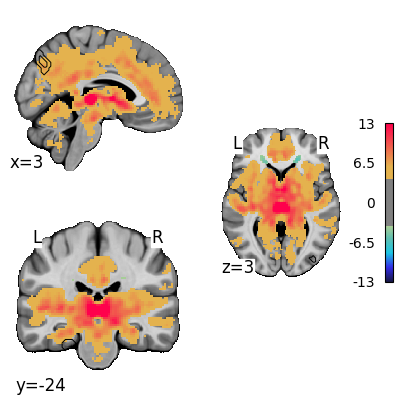

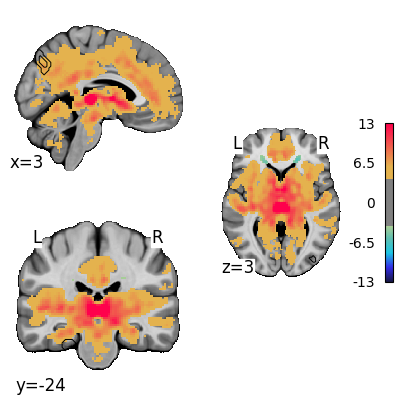

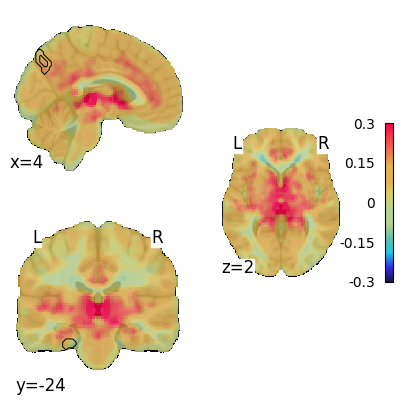

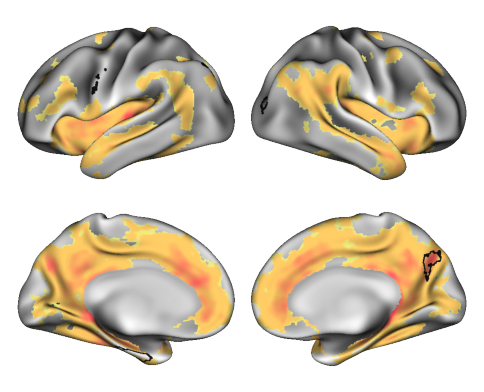

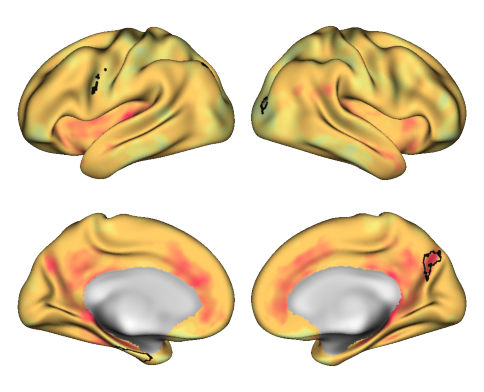

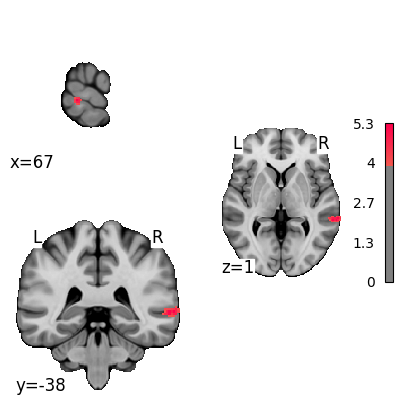

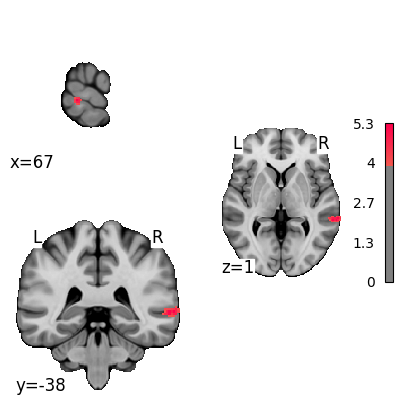

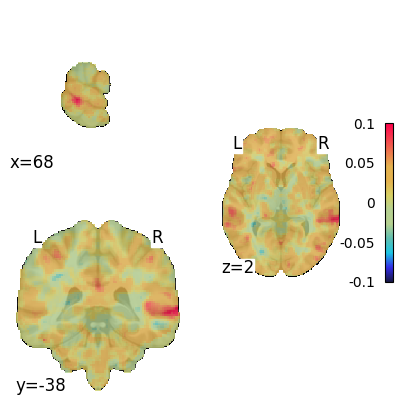

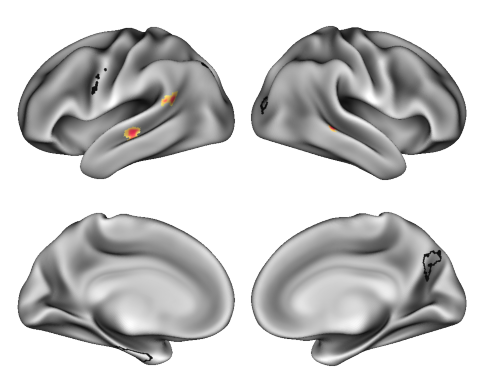

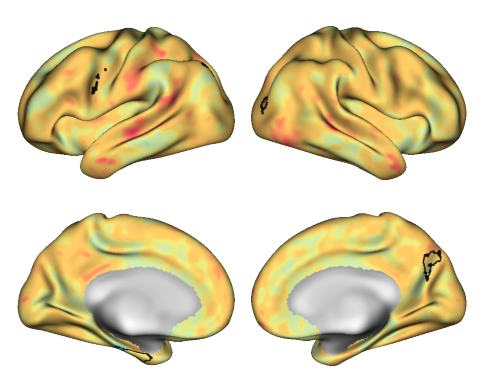

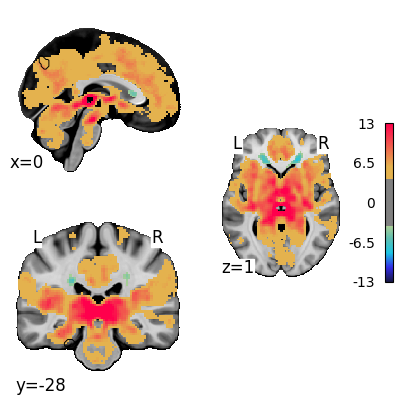

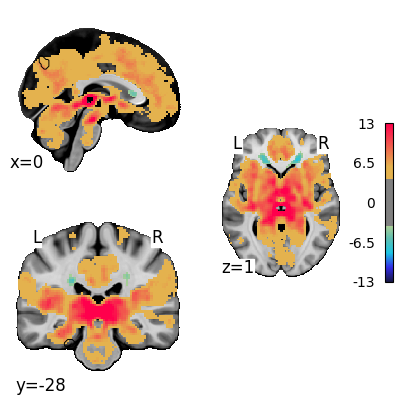

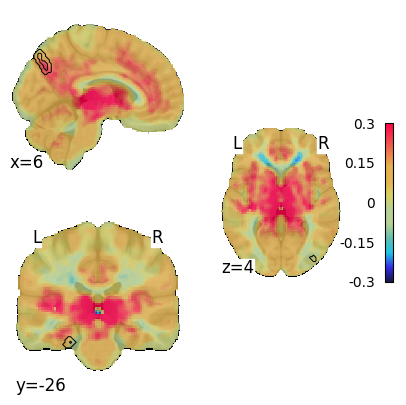

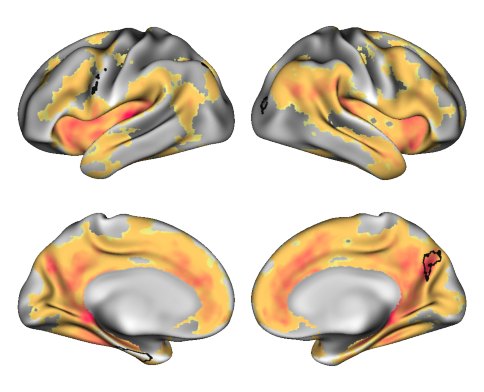

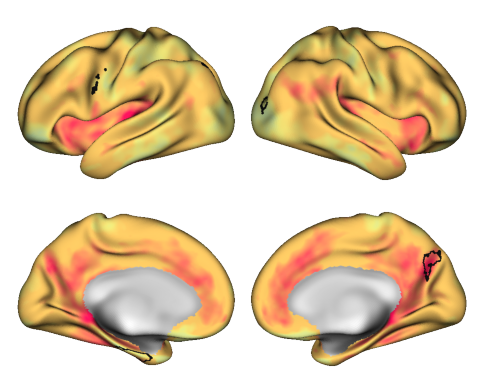

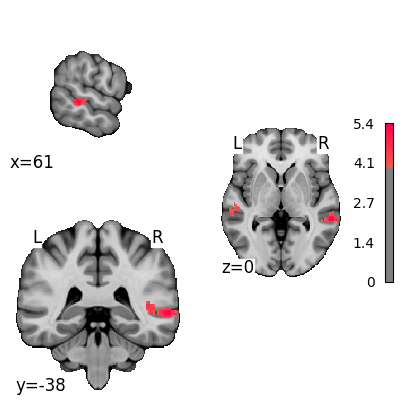

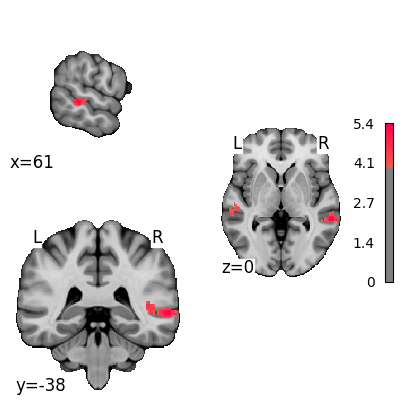

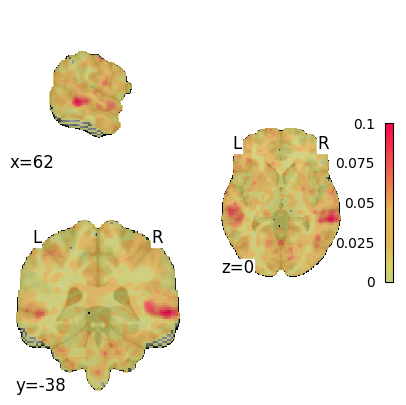

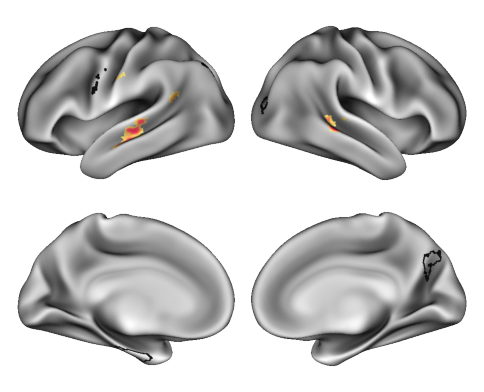

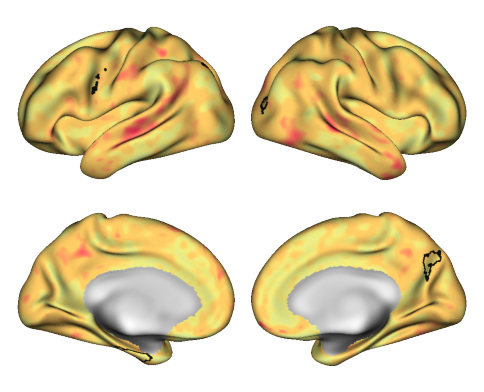

In [10]:
# Setup directories and file paths
group_drawn_dir = op.join(deriv_dir, "hb-conn/group-drawn/habenula")
group_atlas_dir = op.join(deriv_dir, "hb-conn/group-atlas/habenula")

group_dirs = [group_drawn_dir, group_atlas_dir]

for group_dir in group_dirs:
    group_avg_dir = op.join(group_dir, "averaged")
    group_diff_dir = op.join(group_dir, "difference")

    makedirs(group_avg_dir, exist_ok=True)
    makedirs(group_diff_dir, exist_ok=True)

    # File paths
    brik_fn = op.join(
        group_dir, "sub-group_task-rest_desc-1S2StTesthabenula_briks+tlrc.BRIK"
    )
    table_fn = op.join(group_dir, "sub-group_task-rest_desc-1S2StTesthabenula_table.txt")
    cluster_fn = op.join(
        group_dir, "clustsim", "clustsim_out.NN2_2sided.1D"
    )
    nii_1s_fn = op.join(
        group_avg_dir, "sub-group_task-rest_desc-1SampletTest.nii.gz"
    )
    nii_2s_fn = op.join(
        group_diff_dir, "sub-group_task-rest_desc-2SampletTest.nii.gz"
    )

    # Load cluster correction table
    column_names = [".10000", ".05000", ".02000", ".01000"]
    cluster_df = pd.read_table(cluster_fn, skiprows=8, delim_whitespace=True, names=column_names)
    cluster_df = cluster_df.reset_index()
    cluster_df.rename(columns={'index': 'pthr'}, inplace=True)
    print("Cluster correction table:")
    print(cluster_df)

    # Analysis parameters
    brik_idx = [8, 10]
    nii_fns = [nii_1s_fn, nii_2s_fn]
    tests = ["1s", "2s"]
    alpha = ".01000"
    pthrs = [0.0001, 0.0001]
    cohen_thresh = 0

    # Load participant data for effect size calculations
    data_df = pd.read_csv(table_fn, sep="\t")
    n_sub = data_df.groupby("group").size().sum()
    n_sub_1, n_sub_2 = data_df.groupby("group").size().values
    print(f"Total subjects: {n_sub}, Group sizes: {n_sub_1}, {n_sub_2}")

    # Process each test type (1-sample and 2-sample)
    for brik_i, nii_fn, test, pthr in zip(brik_idx, nii_fns, tests, pthrs):
        print(f"\n=== Processing {test_dict[test]} ===")
        
        # Check if the output file already exists
        if not os.path.exists(nii_fn):
            # determine which group we're processing by the parent directory name
            parent_base = op.basename(op.dirname(group_dir))
            if parent_base == "group-drawn":
                print(f"Creating {nii_fn} from drawn group...")
                convert = f"3dAFNItoNIFTI -prefix {nii_fn} {brik_fn}[{brik_i}]"
                os.system(convert)
            elif parent_base == "group-atlas":
                print(f"Creating {nii_fn} for group-atlas...")
                if test == "1s":
                    convert = f"3dAFNItoNIFTI -prefix {nii_fn} {brik_fn}[{brik_i}]"
                    os.system(convert)
                elif test == "2s":
                    # create an absolute-valued difference map on disk
                    convert = f"3dcalc -a {brik_fn}'[{brik_i}]' -expr 'abs(a)' -prefix {nii_fn}"
                    os.system(convert)
            else:
                raise RuntimeError(f"Unexpected group directory parent: {parent_base}")
        else:
            print(f"File {nii_fn} already exists, skipping conversion.")
        
        # Load and threshold images
        nii_img = nib.load(nii_fn)

        # For two-sample (group-difference) maps, ensure values are positive
        # by taking the absolute value if necessary. This is a safety net
        # but the on-disk nifti should already be absolute from the 3dcalc above.
        if test == "2s":
            try:
                nii_arr_raw = masker.transform(nii_img)
                if np.nanmax(nii_arr_raw) <= 0:
                    # all non-positive -> take absolute
                    nii_arr_pos = np.abs(nii_arr_raw)
                    nii_img = masker.inverse_transform(nii_arr_pos)
            except Exception:
                img = nib.load(nii_fn)
                data = img.get_fdata()
                if np.nanmax(data) <= 0:
                    img_pos = nib.Nifti1Image(np.abs(data), img.affine, img.header)
                    nii_img = img_pos

        z_thresh = p_to_z(pthr)
        clust_ext = cluster_df.loc[cluster_df["pthr"] == pthr, alpha].values[0]
        nii_thr_img = threshold_img(nii_img, z_thresh, cluster_threshold=clust_ext)
        print(f"Cluster extent: {clust_ext}, p-threshold: {pthr}, z-threshold: {z_thresh}")
        
        # Calculate effect sizes (Cohen's d)
        nii_arr = masker.transform(nii_img)
        if test == "1s":
            nii_cohen_arr = nii_arr / np.sqrt(n_sub)
        elif test == "2s":
            nii_cohen_arr = nii_arr / (np.sqrt(n_sub_1) + np.sqrt(n_sub_2))
        
        nii_cohen_img = masker.inverse_transform(nii_cohen_arr)
        
        # Create contour masks for visualization
        nii_thr_arr = masker.transform(nii_thr_img)
        nii_contour_arr = np.zeros_like(nii_thr_arr)
        nii_contour_arr[(nii_thr_arr > z_thresh) | (nii_thr_arr < -z_thresh)] = 1
        nii_contour_img = masker.inverse_transform(nii_contour_arr)
        nii_contour_img_3d = index_img(nii_contour_img, 0)
        
        # Set visualization parameters
        vmax = round(np.max(np.abs(nii_thr_arr)), 2)
        vmax = 13 if vmax > 13 else vmax
        c_vmax = 0.1 if test == "2s" else 0.3
        
        # Generate cluster table and save thresholded images
        clusters = get_clusters_table(
            nii_thr_img, z_thresh, two_sided=True
        )
        print("Significant clusters:")
        print(clusters)
        
        # Save thresholded images to appropriate directories
        if test == "1s":
            thresh_fn = op.join(group_avg_dir, f"sub-group_task-rest_desc-1SampletTest_thresh.nii.gz")
        elif test == "2s":
            thresh_fn = op.join(group_diff_dir, f"sub-group_task-rest_desc-2SampletTest_thresh.nii.gz")
        
        nib.save(nii_thr_img, thresh_fn)
        print(f"Saved thresholded nifti: {thresh_fn}")
        
        # Generate all visualizations
        print("Generating visualizations...")
        
        # First, get coordinates from the thresholded statistical map
        from nilearn.plotting import find_xyz_cut_coords
        coords = find_xyz_cut_coords(nii_thr_img, activation_threshold=z_thresh)
        
        stat_fig = plot_vol(nii_thr_img, z_thresh, vmax=vmax, cmap=CMAP)
        vol_fig = plot_vol(nii_thr_img, z_thresh, vmax=vmax, cmap=CMAP)
        cohen_fig = plot_vol(
            nii_cohen_img,
            cohen_thresh,
            mask_contours=nii_contour_img_3d,
            vmax=c_vmax,
            alpha=0.8,
            cmap=CMAP,
        )
        surf_fig = plot_surf(nii_thr_img, mask_contours=nii_contour_img_3d, vmax=vmax, cmap=CMAP)
        cohen_surf_fig = plot_surf(
            nii_cohen_img, mask_contours=nii_contour_img_3d, vmax=c_vmax, cmap=CMAP
        )
        
        # Prepare data for decoding — use absolute values for 2-sample maps
        if test == "1s":
            nii_pos_arr = np.where(nii_arr > 0, nii_arr, 0)
            img_to_decode = masker.inverse_transform(nii_pos_arr)
        elif test == "2s":
            nii_abs_arr = np.abs(nii_arr)
            nii_pos_arr = np.where(nii_abs_arr > 0, nii_abs_arr, 0)
            img_to_decode = masker.inverse_transform(nii_pos_arr)
        
        # Save figures to appropriate directories
        if test == "1s":
            fig_save_dir = group_avg_dir
        elif test == "2s":
            fig_save_dir = group_diff_dir
        
        vol_fig.savefig(op.join(fig_save_dir, f"{test}_volume_hcpex.png"), bbox_inches="tight", dpi=300)
        cohen_fig.savefig(op.join(fig_save_dir, f"{test}_volume-cohen_hcpex.png"), bbox_inches="tight", dpi=300)
        surf_fig.savefig(op.join(fig_save_dir, f"{test}_surface_hcpex.png"), bbox_inches="tight", dpi=300)
        cohen_surf_fig.savefig(op.join(fig_save_dir, f"{test}_surface-cohen_hcpex.png"), bbox_inches="tight", dpi=300)
        
        print(f"Saved figures to {fig_save_dir}")
        print("="*50)

Generating interactive plots for: Group Average (One-Sample T-Test)
Using Custom Colormap (CMAP), Threshold Z = 3.89, Vmax = 13.0


/Users/chloehampson/Desktop/habenula-comparison/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:820: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



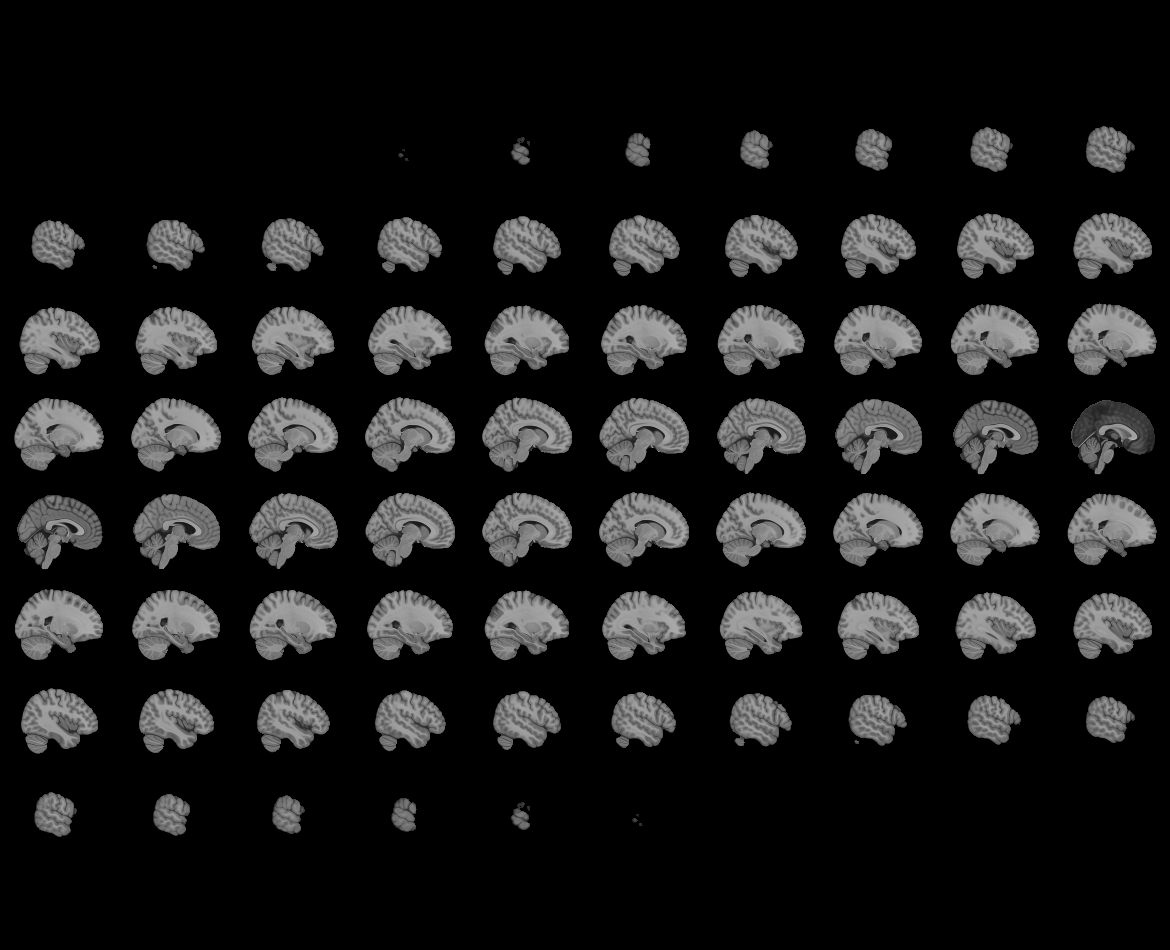
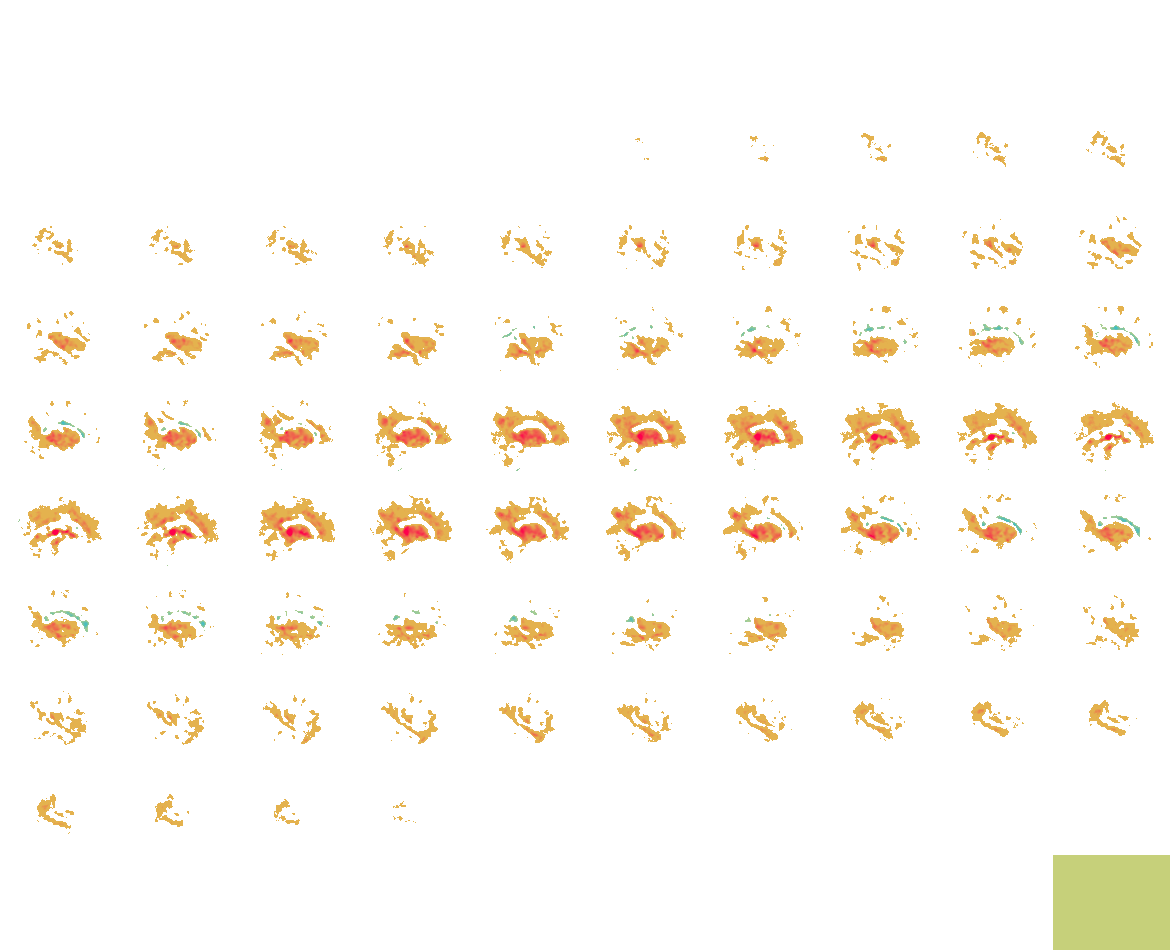

In [13]:
from nilearn.plotting import view_img, view_surf
from nilearn.surface import vol_to_surf

# =================================================================
# 1. SELECT THE MAP YOU WANT TO INTERACTIVELY VIEW
# =================================================================
# Change this to "1s" or "2s" depending on what you want to view
view_target = "1s"  

# Dynamically pull parameters matching your loop's configuration
if view_target == "1s":
    target_dir = op.join(group_drawn_dir, "averaged")
    img_fn = op.join(target_dir, "sub-group_task-rest_desc-1SampletTest.nii.gz")
    plot_vmax = 13.0  # Or set to your preferred maximum styling limit
elif view_target == "2s":
    target_dir = op.join(group_drawn_dir, "difference")
    img_fn = op.join(target_dir, "sub-group_task-rest_desc-2SampletTest.nii.gz")
    plot_vmax = 6.0

# Calculate the exact Z-threshold used during your loop (p=0.0001 -> z≈3.89)
interactive_z_thresh = p_to_z(0.0001) 

# Load the unthresholded map so you can dynamically slide the threshold slider in the browser!
img_to_view = nib.load(img_fn)

print(f"Generating interactive plots for: {test_dict[view_target]}")
print(f"Using Custom Colormap (CMAP), Threshold Z = {interactive_z_thresh:.2f}, Vmax = {plot_vmax}")

# =================================================================
# OPTION A: INTERACTIVE 3D VOLUME VIEWER
# =================================================================
# This creates a clickable 3D view mapping coordinates directly in your browser
volume_viewer = view_img(
    stat_map_img=img_to_view,
    bg_img=datasets.load_mni152_template(resolution=2),
    threshold=interactive_z_thresh,
    vmax=plot_vmax,
    cmap=CMAP,  # Uses your custom hex code colormap seamlessly!
    title=f"Interactive Volume: {test_dict[view_target]}",
    colorbar=True
)

# To save this view as a shareable webpage file, uncomment the line below:
volume_viewer.save_as_html(op.join(target_dir, f"{view_target}_interactive_volume.html"))


# =================================================================
# OPTION B: INTERACTIVE CORTICAL SURFACE VIEWER
# =================================================================
# Projecting volume data to standard fsaverage5 surface mesh vertices
fsaverage = datasets.fetch_surf_fsaverage('fsaverage5')
surf_data_lh = vol_to_surf(img_to_view, fsaverage.pial_left, interpolation='linear')

surface_viewer = view_surf(
    surf_mesh=fsaverage.infl_left, 
    surf_map=surf_data_lh,
    bg_map=fsaverage.sulc_left,
    threshold=interactive_z_thresh,
    vmax=plot_vmax,
    cmap=CMAP,  # Uses the exact same color scheme
    title=f"Interactive Left Hemisphere Surface: {test_dict[view_target]}"
)

# To save this view as a shareable webpage file, uncomment the line below:
surface_viewer.save_as_html(op.join(target_dir, f"{view_target}_interactive_surface.html"))


# =================================================================
# DISPLAY THE RESULT IN YOUR NOTEBOOK
# =================================================================
# Jupyter can render one viewer per cell layout execution. 
# Swap the variable name below to 'surface_viewer' to display the surface instead!
volume_viewer

In [17]:
import html
from nilearn.plotting import view_img

# Central save directory right inside hb-conn
hb_conn_dir = op.join(deriv_dir, "hb-conn")
interactive_z_thresh = p_to_z(0.0001)

# POINTING TO THE CLUSTER-THRESHOLDED NIFTI FILES (_thresh.nii.gz)
paths = {
    "1s_atlas": op.join(hb_conn_dir, "group-atlas/habenula/averaged/sub-group_task-rest_desc-1SampletTest_thresh.nii.gz"),
    "1s_drawn": op.join(hb_conn_dir, "group-drawn/habenula/averaged/sub-group_task-rest_desc-1SampletTest_thresh.nii.gz"),
    "2s_atlas": op.join(hb_conn_dir, "group-atlas/habenula/difference/sub-group_task-rest_desc-2SampletTest_thresh.nii.gz"),
    "2s_drawn": op.join(hb_conn_dir, "group-drawn/habenula/difference/sub-group_task-rest_desc-2SampletTest_thresh.nii.gz"),
}

print("1/3 Loading cluster-thresholded NIfTI volumes and generating Nilearn views...")

# ---- 1-SAMPLE VIEWS ----
viewer_1s_atlas = view_img(
    stat_map_img=nib.load(paths["1s_atlas"]),
    bg_img=datasets.load_mni152_template(resolution=2),
    threshold=interactive_z_thresh, vmax=13.0, cmap=CMAP,
    title="1s Test: Group-Atlas Mask (Cluster-Corrected)", colorbar=True
)
viewer_1s_drawn = view_img(
    stat_map_img=nib.load(paths["1s_drawn"]),
    bg_img=datasets.load_mni152_template(resolution=2),
    threshold=interactive_z_thresh, vmax=13.0, cmap=CMAP,
    title="1s Test: Group-Drawn Mask (Cluster-Corrected)", colorbar=True
)

# ---- 2-SAMPLE VIEWS ----
viewer_2s_atlas = view_img(
    stat_map_img=nib.load(paths["2s_atlas"]),
    bg_img=datasets.load_mni152_template(resolution=2),
    threshold=interactive_z_thresh, vmax=6.0, cmap=CMAP,
    title="2s Test: Group-Atlas Mask (Cluster-Corrected)", colorbar=True
)
viewer_2s_drawn = view_img(
    stat_map_img=nib.load(paths["2s_drawn"]),
    bg_img=datasets.load_mni152_template(resolution=2),
    threshold=interactive_z_thresh, vmax=6.0, cmap=CMAP,
    title="2s Test: Group-Drawn Mask (Cluster-Corrected)", colorbar=True
)

print("2/3 Extracting and safely encoding HTML viewports...")
html_1s_atlas_esc = html.escape(viewer_1s_atlas.get_standalone())
html_1s_drawn_esc = html.escape(viewer_1s_drawn.get_standalone())
html_2s_atlas_esc = html.escape(viewer_2s_atlas.get_standalone())
html_2s_drawn_esc = html.escape(viewer_2s_drawn.get_standalone())

print("3/3 Assembling layout dashboard matrix...")
master_dashboard_template = f"""
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Master Habenula Functional Connectivity Dashboard</title>
    <style>
        body {{
            font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, Helvetica, Arial, sans-serif;
            margin: 0;
            padding: 24px;
            background-color: #f3f4f6;
            color: #1f2937;
        }}
        .dashboard-header {{
            text-align: center;
            margin-bottom: 30px;
            padding-bottom: 20px;
            border-bottom: 3px solid #e5e7eb;
        }}
        .dashboard-header h1 {{ margin: 0 0 8px 0; font-size: 28px; color: #111827; }}
        .dashboard-header p {{ margin: 0; font-size: 15px; color: #4b5563; }}
        
        .section-title {{
            font-size: 22px;
            font-weight: 700;
            color: #111827;
            margin-top: 40px;
            margin-bottom: 16px;
            padding-left: 8px;
            border-left: 5px solid #3b82f6;
        }}
        .section-title.two-sample {{
            border-left-color: #ef4444;
        }}

        .dashboard-grid {{
            display: flex;
            gap: 24px;
            width: 100%;
            box-sizing: border-box;
            margin-bottom: 20px;
        }}
        .card {{
            flex: 1;
            background: #ffffff;
            border: 1px solid #e5e7eb;
            border-radius: 10px;
            box-shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.1), 0 2px 4px -1px rgba(0, 0, 0, 0.06);
            overflow: hidden;
            display: flex;
            flex-direction: column;
        }}
        .card-header {{
            background-color: #f9fafb;
            padding: 14px 20px;
            font-weight: 600;
            font-size: 16px;
            color: #374151;
            border-bottom: 1px solid #e5e7eb;
        }}
        .viewer-frame {{
            width: 100%;
            height: 600px;
            border: none;
            margin: 0;
            padding: 0;
        }}
    </style>
</head>
<body>

    <div class="dashboard-header">
        <h1>Habenula Functional Connectivity Analysis</h1>
        <p><strong>Statistical Threshold:</strong> Z ≥ {interactive_z_thresh:.2f} (p < 0.0001) | <strong>Cluster Corrected</strong> via 3dClustSim</p>
    </div>

    <div class="section-title">1-Sample t-Test (Group Average Activation Maps)</div>
    <div class="dashboard-grid">
        <div class="card">
            <div class="card-header">1s Test: Group-Atlas Mask (Cluster-Corrected)</div>
            <iframe class="viewer-frame" srcdoc="{html_1s_atlas_esc}"></iframe>
        </div>
        <div class="card">
            <div class="card-header">1s Test: Group-Drawn Mask (Cluster-Corrected)</div>
            <iframe class="viewer-frame" srcdoc="{html_1s_drawn_esc}"></iframe>
        </div>
    </div>

    <div class="section-title two-sample">2-Sample t-Test (Group Difference Activation Maps)</div>
    <div class="dashboard-grid">
        <div class="card">
            <div class="card-header">2s Test: Group-Atlas Mask (Cluster-Corrected)</div>
            <iframe class="viewer-frame" srcdoc="{html_2s_atlas_esc}"></iframe>
        </div>
        <div class="card">
            <div class="card-header">2s Test: Group-Drawn Mask (Cluster-Corrected)</div>
            <iframe class="viewer-frame" srcdoc="{html_2s_drawn_esc}"></iframe>
        </div>
    </div>

</body>
</html>
"""

# Save out the master single-file HTML document
master_save_path = op.join(hb_conn_dir, "habenula_connectivity_master_dashboard.html")
with open(master_save_path, "w", encoding="utf-8") as f:
    f.write(master_dashboard_template)

print(f"\nSuccess! Combined interactive dashboard saved to:\n{master_save_path}")

1/3 Loading cluster-thresholded NIfTI volumes and generating Nilearn views...


/Users/chloehampson/Desktop/habenula-comparison/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:820: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/Users/chloehampson/Desktop/habenula-comparison/.venv/lib/python3.9/site-packages/nilearn/plotting/html_document.py:65: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  warnings.warn(
/Users/chloehampson/Desktop/habenula-comparison/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:820: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/Users/chloehampson/Desktop/habenula-comparison/.venv/lib/python3.9/site-packages/nilearn/plotting/html_document.py:65: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megaby

2/3 Extracting and safely encoding HTML viewports...
3/3 Assembling layout dashboard matrix...

Success! Combined interactive dashboard saved to:
./dset/derivatives/hb-conn/habenula_connectivity_master_dashboard.html


/Users/chloehampson/Desktop/habenula-comparison/.venv/lib/python3.9/site-packages/nilearn/plotting/html_document.py:65: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  warnings.warn(
